Question 1: What is Detectron2 and how does it differ from previous object detection
frameworks?
Ans:

Detectron2 is a popular open-source software system for object detection, segmentation, and other visual recognition tasks developed by Facebook AI Research (FAIR). It is a ground-up rewrite of the original Detectron framework, designed for both rapid research and large-scale production use.

Key Features and Capabilities:
Extensive Model Zoo: Includes state-of-the-art implementations of Faster R-CNN, Mask R-CNN, RetinaNet, and newer models like Cascade R-CNN and Panoptic FPN.
Diverse Vision Tasks: Supports bounding-box detection, instance and semantic segmentation, panoptic segmentation, keypoint detection, and dense pose estimation.
Modular Design: Its highly modular architecture allows developers to easily customize backbones, heads, and training pipelines.
Production Tools: Features like Detectron2Go facilitate model conversion for mobile and cloud deployment, including network quantization.

Differences from Previous Frameworks
Detectron2 introduces several significant improvements over the original Detectron and other early frameworks:
Framework Shift (PyTorch): While the original Detectron was built on Caffe2, Detectron2 is built entirely on PyTorch. This allows for dynamic computation graphs, making it more intuitive for debugging and faster prototyping.
Speed and Performance: The entire training pipeline has been moved to GPUs, resulting in much faster training times compared to its predecessors.
Unified API: Unlike earlier, fragmented libraries, Detectron2 provides a single, unified interface for multiple computer vision tasks, reducing the need for separate codebases for detection versus segmentation.
Enhanced Accuracy and Flexibility: Compared to single-stage frameworks like YOLO (optimized for speed), Detectron2 uses a multi-stage approach that generally offers higher accuracy for complex scenes and large datasets.
Better Training Stability: It implements modern defaults such as L1 loss instead of smooth L1 loss and improved ROIAlign versions, which can lead to better box accuracy.

Question 2: Explain the process and importance of data annotation when working with
Detectron2.
Ans:
Data annotation is the process of labeling, tagging, or segmenting images to create "ground truth" data—the accurate answer key used to train AI models. In Detectron2, which is designed for advanced computer vision tasks like object detection, instance segmentation, and keypoint detection, annotation transforms raw images into structured data that allows the model to learn to identify objects, their precise boundaries, and their categories.

mportance of Data Annotation in Detectron2
High-quality annotations are directly responsible for the accuracy and performance of a Detectron2 model.
Enables Learning: Without annotations, a neural network cannot learn patterns.
Defines Precision: For instance segmentation, pixel-perfect polygon annotations allow Detectron2 to differentiate between overlapping objects.
Reduces Bias & Errors: Accurate, consistent, and diverse labeling helps the model generalize to new, unseen data.
Defines Task Complexity: Annotations inform the model of the task type—bounding boxes for simple detection, masks for segmentation, or keypoints for pose estimation.

Process of Data Annotation for Detectron2
The process follows a structured workflow to convert raw images into a format digestible by the Detectron2 library, typically following the COCO dataset format.
1. Data Collection and Preparation
Collect diverse images representing real-world scenarios, including varying backgrounds, lighting, and angles.
Split the dataset into training, validation, and testing sets.
2. Annotation Tool Selection
Several tools can be used to annotate images for Detectron2:
Roboflow: Popular for organizing datasets and exporting directly into Detectron2 COCO JSON format.
Labelme: Excellent for creating custom polygon masks for instance segmentation.
CVAT or VGG Image Annotator (VIA): Other widely used open-source tools.

3. Labeling the Data
Bounding Boxes: Draw rectangles around target objects for object detection.
Polygons/Masks: Outline the exact boundary of objects for segmentation.
Keypoints: Label specific joints or points for pose detection.
4. Exporting and Formatting
Detectron2 generally requires data in a specific JSON format, often referred to as COCO format. The exported annotation file should contain image_id, category_id, bbox, segmentation (polygons), and area.
5. Registering the Dataset
Once annotated, the custom dataset must be registered within the Detectron2 framework to be used in training.

Metadata: Define the dataset catalog, including image paths and annotations.
register_dataset function: Register training and validation sets.
6. Verification
Before training, use Detectron2’s Visualizer class to visualize the annotation results to ensure bounding boxes and masks are correctly aligned with the objects.


Question 3: Describe the steps involved in training a custom object detection model
using Detectron2.
Ans:
Training a custom object detection model with Detectron2 involves a standard workflow ranging from environment setup to final model evaluation.

1. Installation and Setup
Install Dependencies: First, set up a virtual environment and install core dependencies, including PyTorch and torchvision.
Install Detectron2: Install the library directly from the source or via pre-built wheels that match your CUDA version.
Verify GPU Access: Ensure that CUDA is correctly recognized so the model can leverage GPU acceleration for faster training.
 2. Dataset Preparation and Registration
Format Annotations: Prepare your images and labels in the COCO JSON format, which is the preferred standard for Detectron2. Tools like CVAT or LabelMe can be used to generate these.
Register the Dataset: Use the register_coco_instances function to tell Detectron2 where your images and annotation files are located.
Set Metadata: Define class names (e.g., "car", "person") in the MetadataCatalog to ensure correct labeling during visualization and inference.

3. Training Configuration
Load Base Model: Choose a pre-trained model architecture (like Faster R-CNN) from the Detectron2 Model Zoo.
Customize Hyperparameters: Configure key training settings using get_cfg():
cfg.MODEL.ROI_HEADS.NUM_CLASSES: Set this to the number of custom classes in your dataset.
cfg.SOLVER.BASE_LR: Adjust the learning rate for fine-tuning.
cfg.SOLVER.MAX_ITER: Define the total number of training iterations.
cfg.MODEL.WEIGHTS: Point to the initial weights from the Model Zoo to start fine-tuning.
4. Model Training
Initialize Trainer: Use the DefaultTrainer class with your custom configuration.
Run Training: Start the training process using trainer.train(). Detectron2 will automatically handle data loading, loss calculation, and weight updates.
5. Evaluation and Inference
Run Inference: Once training is complete, create a DefaultPredictor using the saved weights (model_final.pth).
Visualize Results: Use the Visualizer class to overlay predicted bounding boxes and class labels onto test images to confirm performance.
Evaluate Metrics: Compute standard metrics such as mAP (mean Average Precision) on a held-out validation set to quantify the model's accuracy.



Question 4: What are evaluation curves in Detectron2, and how are metrics like mAP
and IoU interpreted?
Ans:

In Detectron2, evaluation curves and metrics (like mAP and IoU) are tools for quantifying the accuracy of object detection and instance segmentation models, primarily using COCO dataset standards. These metrics help identify how well a model detects objects (bounding boxes) and segments them (masks), tracking performance over training time or against varying difficulty thresholds.
1. Key Evaluation Metrics
Intersection over Union (IoU)
IoU measures the spatial overlap between the predicted bounding box and the ground truth box, ranging from 0 to 1.
Interpretation: A higher IoU indicates a better, tighter fit.
IoU = 1: Perfect, absolute overlap.
IoU = 0: No overlap.
Role: It defines whether a detection is a True Positive (TP) or False Positive (FP) based on a threshold (e.g.,IoU > 0.5).

Mean Average Precision (mAP)
mAP is the average precision (AP) calculated across all classes. In Detectron2 (using COCO evaluator), this is the primary metric.

AP50 (or AP@0.50): Average precision at a 50% IoU threshold. Often used for looser, more forgiving localization.
AP75 (or AP@0.75): Average precision at a 75% IoU threshold. Measures stricter localization.
mAP @ 0.50:0.95 (or just AP): The main COCO metric, averaging AP over 10 different IoU thresholds (0.5,0.55,....,0.95).

Other Key Metrics in Detectron2:

APl/APm/APs: AP for Large, Medium, and Small objects respectively.
AP_box: AP for bounding boxes.
AP_mask: AP for instance segmentation masks.
2. Evaluation Curves
While Detectron2 reports scalar values at the end of evaluation, "evaluation curves" often refer to the visualization of these metrics over training time (iterations/epochs) using Tools like TensorBoard.
mAP vs. Iterations: A curve showing increasing mAP indicates the model is learning to detect better as training progresses.
Loss vs. Iterations: Shows training and validation loss, helping detect overfitting.
PR Curve (Precision-Recall Curve): Although less standard in default printed logs, Detectron2 allows generating PR curves to show the trade-off between precision and recall at different confidence thresholds.

3. How to Interpret Results
When you run Trainer.test() or use COCOEvaluator, the output looks like this:

OrderedDict([('bbox', {'AP': 55.2, 'AP50': 70.1, ...})])

If AP50 is high but AP75 is low: The model locates objects roughly but fails to tighten the box around them accurately.
If APs is low: The model struggles to detect small objects.
If AP50:0.95 increases but AP50 plateaus: The model is getting better at precise localization without necessarily finding more objects.

4. Implementation in Detectron2
You can use the built-in COCOEvaluator to compute these metrics for custom datasets:

cODE:


from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader

# Use COCOEvaluator for AP/mAP
evaluator = COCOEvaluator("dataset_name", cfg, True, output_dir="./output/")
val_loader = build_detection_test_loader(cfg, "dataset_name")
inference_on_dataset(trainer.model, val_loader, evaluator)


Question 5: Compare Detectron2 and TFOD2 in terms of features, performance, and
ease of use.
Ans:
Detectron2 and the TensorFlow Object Detection API 2 (TFOD2) are both powerful, industry-standard frameworks for computer vision tasks, but they cater to different needs based on their underlying ecosystems (PyTorch vs. TensorFlow). Generally, Detectron2 is preferred for research, flexibility, and state-of-the-art accuracy, while TFOD2 is often preferred for deployment, particularly within Google Cloud/TensorFlow ecosystems.
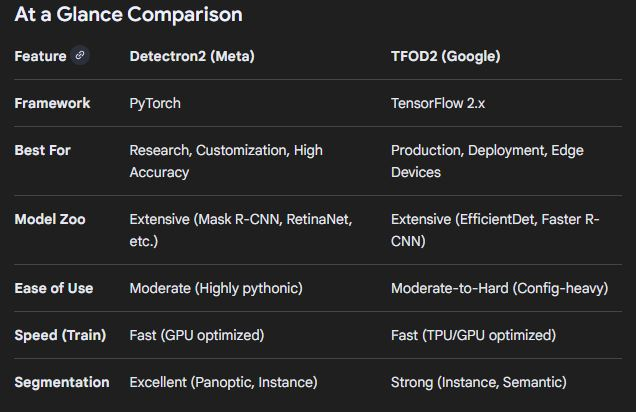

1. Features
Detectron2: Built by Meta AI in PyTorch, it is known for its highly modular design, allowing developers to easily change any component (backbone, head, loss function). It natively supports object detection, instance segmentation, panoptic segmentation, and keypoint detection (DensePose).
TFOD2: Built by Google, it is strongly geared toward deployment. Its "Model Zoo" features a wide variety of pre-trained models ranging from lightweight (SSD MobileNet) to highly accurate (EfficientDet). It is strongly integrated into the TensorFlow ecosystem, making it easier to export models to TFLite (mobile) or TFServing (cloud).
2. Performance
Accuracy: Detectron2 often provides superior accuracy on complex tasks because it specializes in two-stage detectors (like Mask R-CNN) and frequently incorporates the latest research papers (e.g., PointRend, ViTDet).
Inference Speed: While Detectron2 is fast, TFOD2 often wins in production speed, particularly using EfficientDet or SSD architectures designed for inference speed.
Training: Both frameworks are fast and support multi-GPU training. Detectron2's transition to PyTorch has made it very efficient.

3. Ease of Use
Detectron2: Considered more pythonic and intuitive for researchers familiar with PyTorch. Customizing architectures involves rewriting Python classes, which provides high flexibility. Its documentation is strong, but it expects a good understanding of underlying detection mechanisms.
TFOD2: Relies heavily on config files (.config files) to define model parameters, training paths, and hyperparameters. This can make initial setup complex. However, once the configuration is mastered, training on custom data is straightforward.
Key Takeaways
Choose Detectron2 if:
You are doing research or need cutting-edge accuracy.
You prefer PyTorch for its dynamic computational graphs.
You need advanced capabilities like panoptic segmentation or custom backbone designs.
You need to rapidly iterate and customize the architecture.
Choose TFOD2 if:
You are committed to the TensorFlow/Keras ecosystem.
Your goal is deployment on edge devices (TFLite) or servers (TFServing).
You need to use EfficientDet, which provides top-tier speed/accuracy tradeoffs.
You are training a large, production-grade model on Google Cloud.







In [ ]:
#Question 6: Write Python code to install Detectron2 and verify the installation.

import subprocess
import sys

def install_detectron2():
    # Install dependencies first (PyYAML and Cython are often required)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pyyaml==5.1", "cython"])

    # Install Detectron2 from source
    # Note: Use --user if you do not have administrative permissions
    subprocess.check_call([
        sys.executable, "-m", "pip", "install",
        "git+https://github.com/facebookresearch/detectron2.git"
    ])

if __name__ == "__main__":
    install_detectron2()

import torch
import detectron2
from detectron2.utils.logger import setup_logger
from detectron2.utils.collect_env import collect_env

# 1. Setup logger
setup_logger()

# 2. Check System Environment
print("--- System Environment ---")
print(collect_env())

# 3. Check PyTorch and CUDA
print("\n--- PyTorch & CUDA Check ---")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

# 4. Check Detectron2 version
print(f"Detectron2 version: {detectron2.__version__}")

# 5. Basic Functional Test (Optional: Loading a model zoo config)
from detectron2 import model_zoo
try:
    config_path = model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml")
    print(f"\nVerification Successful: Successfully accessed Model Zoo at {config_path}")
except Exception as e:
    print(f"\nVerification Failed: {e}")



In [ ]:
#Question 7:Annotate a dataset using any tool of your choice and convert the annotations to COCO format for Detectron2.


import os
from detectron2.data.datasets import register_coco_instances
from detectron2.data import MetadataCatalog, DatasetCatalog

# 1. Register the training and validation sets
# Arguments: (name_of_dataset, metadata_dict, json_file_path, image_root_directory)
register_coco_instances("my_dataset_train", {}, "my_dataset/train/annotations.json", "my_dataset/train")
register_coco_instances("my_dataset_val", {}, "my_dataset/val/annotations.json", "my_dataset/val")

# 2. Access metadata (like class names) automatically parsed from the COCO JSON
metadata = MetadataCatalog.get("my_dataset_train")
print(f"Classes found: {metadata.thing_classes}")

# 3. Verify the data by loading a few samples
dataset_dicts = DatasetCatalog.get("my_dataset_train")
print(f"Successfully loaded {len(dataset_dicts)} images.")






In [ ]:
#Question 8: Write a script to download pretrained weights and configure paths for training in Detectron2.
import os
from detectron2.config import get_cfg
from detectron2 import model_zoo

def get_config_with_weights(config_path, num_classes, train_set, output_dir="./output"):
    """
    Initializes configuration, loads Model Zoo config, and sets weights/paths.
    """
    cfg = get_cfg() #
    # Load architecture configuration from Model Zoo
    cfg.merge_from_file(model_zoo.get_config_file(config_path)) #

    # Configure dataset and output paths
    cfg.DATASETS.TRAIN = (train_set,) #
    cfg.DATASETS.TEST = ()
    cfg.OUTPUT_DIR = output_dir
    os.makedirs(cfg.OUTPUT_DIR, exist_ok=True) #

    # Download and set Pretrained Weights
    cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url(config_path) #

    # Set classes for custom dataset
    cfg.MODEL.ROI_HEADS.NUM_CLASSES = num_classes #

    return cfg





In [ ]:
#Question 9: Show the steps and code to run inference using a trained Detectron2 model on a new image.
import cv2
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog

# 1. Setup Configuration
cfg = get_cfg()
# Use the same config file used for training (e.g., Mask R-CNN)
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5  # Set threshold for this model
cfg.MODEL.WEIGHTS = "path/to/your/model_final.pth" # Path to trained weights
cfg.MODEL.DEVICE = "cuda" # or "cpu" if no GPU is available

# 2. Initialize Predictor
predictor = DefaultPredictor(cfg)

# 3. Load New Image
im = cv2.imread("new_image.jpg")

# 4. Run Inference
outputs = predictor(im)

# 5. Visualize Results
# Use metadata from your registered dataset to show correct class names
v = Visualizer(im[:, :, ::-1], metadata=MetadataCatalog.get(cfg.DATASETS.TRAIN[0]), scale=1.2)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
cv2.imshow("Result", out.get_image()[:, :, ::-1])
cv2.waitKey(0)


In [ ]:
#Question 10: You are assigned to build a wildlife monitoring system to detect and track different animal species in a forest using Detectron2. Describe the end-to-end pipeline from data collection to deploying the model, and how you would handle challenges like occlusion or nighttime detection.


import detectron2
from detectron2.engine import DefaultTrainer
from detectron2.config import get_cfg
from detectron2.data import DatasetCatalog, MetadataCatalog
from detectron2.data.datasets import register_coco_instances
import os

# 1. Register Dataset
register_coco_instances("wildlife_train", {}, "path/to/train.json", "path/to/images")

# 2. Configure Model
cfg = get_cfg()
cfg.merge_from_file("detectron2/configs/COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")
cfg.DATASETS.TRAIN = ("wildlife_train",)
cfg.DATASETS.TEST = ()
cfg.DATALOADER.NUM_WORKERS = 4
cfg.MODEL.WEIGHTS = "detectron2://ImageNetPretrained/MSRA/R-50.pkl" # Pre-trained
cfg.SOLVER.IMS_PER_BATCH = 2
cfg.SOLVER.BASE_LR = 0.00025
cfg.SOLVER.MAX_ITER = 10000
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 5 # Number of animal species

# 3. Train
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=False)
trainer.train()




from detectron2.engine import DefaultPredictor
import cv2

cfg.MODEL.WEIGHTS = "output/model_final.pth"
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.7 # High threshold for accuracy
predictor = DefaultPredictor(cfg)

# Inference on a nighttime image
im = cv2.imread("night_animal.jpg")
outputs = predictor(im)


